# GRIFFIN HR Classification Project
**BUAD 5722 / BUAD 5742 — Spring 2026 — Team 7**
**Steven Alvarado, Anmol Motwani, JR Jones, Brynn Vetrano**

# GRIFFIN Feature Engineering (A4)
## Extract structured features from 103 W&M position descriptions

**Input**: `workday_training.csv` (103 censored PDs with classification labels)  
**Output**: `workday_features.csv` (tabular feature matrix for H2O AutoML)  
**Target**: DHRM Occupational Family (7 classes)

In [4]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [5]:
# Paths — notebook is in notebooks/, project root is one level up
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.join(NOTEBOOK_DIR, "..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")

# Load training data
training_df = pd.read_csv(os.path.join(DATA_DIR, "training", "workday_training.csv"))
print(f"Training data: {training_df.shape}")
print(f"  Columns: {list(training_df.columns)}")

# Load career groups (DHRM reference)
career_groups = pd.read_excel(os.path.join(DATA_DIR, "reference", "career_groups.xlsx"), engine="openpyxl")
print(f"\nCareer groups: {career_groups.shape}")
print(f"  Columns: {list(career_groups.columns)}")

Training data: (103, 6)
  Columns: ['censored_text', 'compensation_grade', 'job_profile_code', 'job_family', 'exempt_status', 'pay_type']

Career groups: (56, 11)
  Columns: ['career_group_name', 'career_group_code', 'occupational_family', 'pay_band_min', 'pay_band_max', 'occ_family_code', 'concept_of_work', 'effective_date', 'source_url', 'source_format', 'data_source']


## Explore the Training Data
Quick look at the label distributions and text characteristics.

In [6]:
print("=== First 3 rows (censored_text truncated to 120 chars) ===")
display_df = training_df.head(3).copy()
display_df["censored_text"] = display_df["censored_text"].str[:120] + "..."
display(display_df)

print(f"\n=== job_family value counts ({training_df['job_family'].nunique()} unique, {training_df['job_family'].isna().sum()} NaN) ===")
print(training_df["job_family"].value_counts().to_string())

print(f"\n=== compensation_grade value counts ===")
print(training_df["compensation_grade"].value_counts().to_string())

print(f"\n=== exempt_status value counts ({training_df['exempt_status'].isna().sum()} NaN) ===")
print(training_df["exempt_status"].value_counts(dropna=False).to_string())

print(f"\n=== pay_type value counts ===")
print(training_df["pay_type"].value_counts().to_string())

print(f"\n=== censored_text length stats ===")
print(training_df["censored_text"].str.len().describe().to_string())

=== First 3 rows (censored_text truncated to 120 chars) ===


,censored_text,compensation_grade,job_profile_code,job_family,exempt_status,pay_type
0,Shellfish Aquaculture Research Farm Intern\nDe...,H02,JP0064,Staff - Lab & Research Support,Nonexempt,Hourly
1,"Executive Assistant, Office of the Vice Provos...",S13,JP0419,Staff - Administrative & Office Support,Exempt,Salary
2,Fiscal Specialist (Office of the Provost)\nDep...,S08,JP0832,Staff - Fiscal Administration,Nonexempt,Salary



=== job_family value counts (30 unique, 3 NaN) ===
job_family
Staff - Administrative & Office Support           14
Staff - Career Services                            9
Staff - Academic Program Administration            8
Staff - Communications                             7
Staff - Lab & Research Support                     7
Staff - Fiscal Administration                      6
Staff - Building Services                          4
Staff - Giving: Annual, Major Gifts, & Planned     4
Staff - Maintenance                                4
Staff - Media & Creative Services                  3
Staff - Alumni Affairs                             3
Staff - Program Management                         3
Staff - User Support                               3
Staff - Security - Law Enforcement Officer         3
Staff - Scientist                                  3
Staff - Athletic Training & Wellbeing              2
Staff - Librarians                                 2
Staff - Security - Non Law Enforceme

## Build W&M Job Family to DHRM Occupational Family Mapping

The 103 PDs use 30 W&M `job_family` labels. We need to collapse them into the 7 DHRM
occupational families that serve as our prediction target.

**Mapping rationale**: Each W&M job family is assigned to the DHRM occupational family
whose career-group descriptions best match the work content.

In [7]:
print("DHRM Occupational Families (7):")
for fam in career_groups["occupational_family"].unique():
    print(f"  {fam}")

# W&M job_family -> DHRM occupational_family mapping
# Keys match the EXACT strings in workday_training.csv
JOB_FAMILY_TO_OCC_FAMILY = {
    # --- Administrative Services ---
    # Office, fiscal, HR, procurement, enrollment, advancement, program admin
    "Staff - Administrative & Office Support":        "Administrative Services",
    "Staff - Fiscal Administration":                  "Administrative Services",
    "Staff - Financial Analysis":                     "Administrative Services",
    "Staff - HR Business Partner":                    "Administrative Services",
    "Staff - Academic Program Administration":        "Administrative Services",
    "Staff - Program Management":                     "Administrative Services",
    "Staff - Career Services":                        "Administrative Services",
    "Staff - Alumni Affairs":                         "Administrative Services",
    "Staff - Giving: Annual, Major Gifts, & Planned": "Administrative Services",
    "Staff - Stewardship & Donor Relations":          "Administrative Services",
    "Staff - Admissions & Enrollment":                "Administrative Services",
    "Staff - Student Services":                       "Administrative Services",
    "Staff - Compliance":                             "Administrative Services",
    "Staff - Community Relations":                    "Administrative Services",

    # --- Educational and Media Services ---
    # Communications, media, library, instructional design, public relations
    "Staff - Communications":                         "Educational and Media Services",
    "Staff - Public Relations":                       "Educational and Media Services",
    "Staff - Media & Creative Services":              "Educational and Media Services",
    "Staff - Librarians":                             "Educational and Media Services",
    "Staff - Instructional Development & Design":     "Educational and Media Services",

    # --- Engineering and Technology ---
    # IT, software, user support, network/systems
    "Staff - Software Programming & Applications":    "Engineering and Technology",
    "Staff - User Support":                           "Engineering and Technology",

    # --- Health and Human Services ---
    # Medical, counseling, wellness, athletic training
    "Staff - Medical":                                "Health and Human Services",
    "Staff - Athletic Training & Wellbeing":          "Health and Human Services",

    # --- Natural Resources and Applied Science ---
    # Research, lab, science
    "Staff - Scientist":                              "Natural Resources and Applied Science",
    "Staff - Lab & Research Support":                 "Natural Resources and Applied Science",

    # --- Public Safety ---
    # Law enforcement, security
    "Staff - Security - Law Enforcement Officer":     "Public Safety",
    "Staff - Security - Non Law Enforcement Officer": "Public Safety",

    # --- Trades and Operations ---
    # Building services, maintenance, athletics operations
    "Staff - Building Services":                      "Trades and Operations",
    "Staff - Maintenance":                            "Trades and Operations",
    "Staff - Athletics Operations":                   "Trades and Operations",
}

# Check for unmapped job families
known_families = training_df["job_family"].dropna().unique()
unmapped = [f for f in known_families if f not in JOB_FAMILY_TO_OCC_FAMILY]
print(f"\nUnmapped job families: {unmapped}")

# Apply mapping
training_df["occ_family"] = training_df["job_family"].map(JOB_FAMILY_TO_OCC_FAMILY)

# Handle 3 rows with NaN job_family -> mark as Unknown
nan_count = training_df["occ_family"].isna().sum()
print(f"\nNaN job_family rows: {nan_count} -> mapped to 'Unknown'")
training_df["occ_family"] = training_df["occ_family"].fillna("Unknown")

print(f"\nocc_family distribution:")
print(training_df["occ_family"].value_counts().to_string())

DHRM Occupational Families (7):
  Administrative Services
  Engineering and Technology
  Trades and Operations
  Health and Human Services
  Educational and Media Services
  Natural Resources and Applied Science
  Public Safety

Unmapped job families: []

NaN job_family rows: 3 -> mapped to 'Unknown'

occ_family distribution:
occ_family
Administrative Services                  55
Educational and Media Services           14
Natural Resources and Applied Science    10
Trades and Operations                     9
Public Safety                             5
Engineering and Technology                4
Unknown                                   3
Health and Human Services                 3


## Feature Extraction Functions

Extract 15 structured features from each censored position description:
- **Budget**: mentions, max dollar amount
- **Supervision**: binary flag, headcount
- **Education**: ordinal level (HS=1 to PhD=5)
- **Experience**: max years mentioned
- **Text length**: raw character count
- **Domain keyword counts**: leadership, technical, research, healthcare, facilities, finance
- **Label-derived**: is_exempt, is_salaried

In [8]:
def extract_budget_mentioned(text):
    """Binary: does text mention dollar amounts or 'budget'"""
    return int(bool(re.search(r'\$[\d,]+|\bbudget\b', text, re.IGNORECASE)))

def extract_budget_amount_max(text):
    """Largest dollar figure found (0 if none)"""
    amounts = re.findall(r'\$([\d,]+)', text)
    if not amounts:
        return 0
    return max(int(a.replace(',', '')) for a in amounts)

def extract_supervises_staff(text):
    """Binary: does this position GIVE supervision to others?
    
    Distinguishes 'supervises staff' (gives) from 'works under supervision'
    (receives). Uses directional patterns that look at the surrounding
    context to determine which side of the supervision relationship
    the position is on.
    """
    # Patterns indicating this position GIVES supervision
    gives_patterns = [
        r'supervises?\s+\w',                     # 'supervises staff', 'supervise the'
        r'(?:will|may|must)\s+supervise',         # 'will supervise'
        r'oversee\s+\w',                          # 'oversee operations'
        r'oversight\s+of',                        # 'oversight of programs'
        r'manage\s+(?:a\s+)?team',                # 'manage a team'
        r'direct\s+reports?',                     # 'direct reports'
        r'lead\s+(?:a\s+)?team',                  # 'lead a team'
        r'responsible\s+for\s+(?:the\s+)?(?:supervision|oversight|management\s+of)',
        r'(?:functional|direct|immediate)\s+supervision\s+(?:of|over)',
        r'supervisory\s+(?:role|responsibilit|duties|authority)',
        r'manage\w*\s+(?:staff|employees?|personnel|workers)',
    ]
    return int(any(re.search(p, text, re.IGNORECASE) for p in gives_patterns))

def extract_receives_supervision(text):
    """Binary: does this position RECEIVE supervision from others?
    
    Useful because entry-level PDs mention 'works under supervision'
    while senior PDs don't — this is signal for pay band level.
    """
    receives_patterns = [
        r'under\s+(?:the\s+)?(?:supervision|direction|guidance)',
        r'(?:reports?|reporting)\s+to',
        r'supervised\s+by',
        r'(?:immediate|direct)\s+supervisor\s+(?:is|will)',
    ]
    return int(any(re.search(p, text, re.IGNORECASE) for p in receives_patterns))

def extract_supervision_count(text):
    """Number of direct reports mentioned (0 if none)"""
    patterns = [
        r'(\d+)\s+(?:direct\s+reports?|staff\s+members?|employees?|subordinates?)',
        r'(?:team\s+of|supervises?|manages?|oversees?)\s+(\d+)',
        r'(\d+)\s+(?:FTE|full.time)',
    ]
    counts = []
    for p in patterns:
        matches = re.findall(p, text, re.IGNORECASE)
        counts.extend(int(m) for m in matches)
    return max(counts) if counts else 0

def extract_education_level(text):
    """Ordinal: 0=not mentioned, 1=HS, 2=Associate, 3=Bachelor, 4=Master, 5=PhD/JD/MD"""
    text_lower = text.lower()
    if any(w in text_lower for w in ['ph.d', 'phd', 'doctorate', 'doctoral', 'j.d.', 'jd', 'm.d.', 'md']):
        return 5
    if any(w in text_lower for w in ["master's", "masters", "master degree", "m.s.", "m.a.", "mba", "m.b.a."]):
        return 4
    if any(w in text_lower for w in ["bachelor's", "bachelors", "bachelor degree", "b.s.", "b.a.",
                                      "undergraduate degree", "four-year degree", "4-year degree"]):
        return 3
    if any(w in text_lower for w in ["associate's", "associates", "associate degree", "two-year", "2-year"]):
        return 2
    if any(w in text_lower for w in ["high school", "ged", "diploma"]):
        return 1
    return 0

def extract_years_experience(text):
    """Max years of experience mentioned (0 if none)"""
    patterns = [
        r'(\d+)\+?\s*years?\s+(?:of\s+)?(?:experience|relevant|professional|related)',
        r'(?:minimum|at\s+least|requires?)\s+(\d+)\s+years?',
    ]
    years = []
    for p in patterns:
        matches = re.findall(p, text, re.IGNORECASE)
        years.extend(int(m) for m in matches)
    return max(years) if years else 0

def count_keywords(text, keywords):
    """Count occurrences of keyword list in text (case-insensitive)"""
    text_lower = text.lower()
    return sum(text_lower.count(kw.lower()) for kw in keywords)

# Domain keyword lists
LEADERSHIP_KEYWORDS = ["manage", "lead", "direct", "supervise", "oversee",
                        "coordinate", "administer", "executive"]
TECHNICAL_KEYWORDS  = ["software", "database", "network", "system", "programming",
                        "technical", "engineer", "IT", "technology", "cyber", "server"]
RESEARCH_KEYWORDS   = ["research", "laboratory", "experiment", "grant", "publication",
                        "scientific", "study", "analysis", "data"]
HEALTHCARE_KEYWORDS = ["patient", "clinical", "medical", "health", "nursing",
                        "therapy", "counseling", "diagnosis", "treatment"]
FACILITIES_KEYWORDS = ["maintenance", "building", "HVAC", "plumbing", "electrical",
                        "custodial", "grounds", "facility", "repair", "construction"]
FINANCE_KEYWORDS    = ["budget", "fiscal", "accounting", "audit", "financial",
                        "procurement", "payroll", "revenue", "expenditure", "tax"]

print("Feature extraction functions defined.")

Feature extraction functions defined.


In [9]:
df = training_df.copy()

# Text-based features
df["budget_mentioned"]       = df["censored_text"].apply(extract_budget_mentioned)
# NOTE: budget_amount_max DROPPED — all zeros because dollar amounts were
# stripped during A3 censoring. Zero-variance features add noise, not signal.
df["supervises_staff"]       = df["censored_text"].apply(extract_supervises_staff)
df["receives_supervision"]   = df["censored_text"].apply(extract_receives_supervision)
df["supervision_count"]      = df["censored_text"].apply(extract_supervision_count)
df["education_level"]        = df["censored_text"].apply(extract_education_level)
df["years_experience"]       = df["censored_text"].apply(extract_years_experience)
df["text_length"]            = df["censored_text"].str.len()

# Domain keyword counts
df["leadership_keywords"] = df["censored_text"].apply(lambda t: count_keywords(t, LEADERSHIP_KEYWORDS))
df["technical_keywords"]  = df["censored_text"].apply(lambda t: count_keywords(t, TECHNICAL_KEYWORDS))
df["research_keywords"]   = df["censored_text"].apply(lambda t: count_keywords(t, RESEARCH_KEYWORDS))
df["healthcare_keywords"] = df["censored_text"].apply(lambda t: count_keywords(t, HEALTHCARE_KEYWORDS))
df["facilities_keywords"] = df["censored_text"].apply(lambda t: count_keywords(t, FACILITIES_KEYWORDS))
df["finance_keywords"]    = df["censored_text"].apply(lambda t: count_keywords(t, FINANCE_KEYWORDS))

# Label-derived features
df["is_exempt"]   = (df["exempt_status"] == "Exempt").astype(int)
df["is_salaried"] = (df["pay_type"] == "Salary").astype(int)

# Feature column list (15 features — budget_amount_max dropped)
feature_cols = [
    "budget_mentioned", "supervises_staff",
    "receives_supervision", "supervision_count",
    "education_level", "years_experience", "text_length",
    "leadership_keywords", "technical_keywords", "research_keywords",
    "healthcare_keywords", "facilities_keywords", "finance_keywords",
    "is_exempt", "is_salaried"
]

print(f"Feature matrix: {df.shape}")
print(f"\nFeature columns ({len(feature_cols)} features):")
for col in feature_cols:
    nonzero = df[col].astype(bool).sum()
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}, nonzero={nonzero}")

Feature matrix: (103, 22)

Feature columns (15 features):
  budget_mentioned: min=0, max=1, mean=0.19, nonzero=20
  supervises_staff: min=0, max=1, mean=0.39, nonzero=40
  receives_supervision: min=0, max=1, mean=0.57, nonzero=59
  supervision_count: min=0, max=30, mean=0.33, nonzero=3
  education_level: min=0, max=5, mean=1.30, nonzero=67
  years_experience: min=0, max=21, mean=1.03, nonzero=9
  text_length: min=1713, max=13098, mean=5502.50, nonzero=103
  leadership_keywords: min=0, max=44, mean=12.49, nonzero=101
  technical_keywords: min=14, max=134, mean=57.31, nonzero=103
  research_keywords: min=0, max=64, mean=6.73, nonzero=75
  healthcare_keywords: min=0, max=24, mean=1.12, nonzero=43
  facilities_keywords: min=0, max=23, mean=1.88, nonzero=40
  finance_keywords: min=0, max=85, mean=5.01, nonzero=56
  is_exempt: min=0, max=1, mean=0.42, nonzero=43
  is_salaried: min=0, max=1, mean=0.78, nonzero=80


## Feature Summary Statistics

In [10]:
print("=== Descriptive statistics for all 15 features ===")
display(df[feature_cols].describe().T.round(2))

print("\n=== Features with zero variance (constant columns) ===")
zero_var = [c for c in feature_cols if df[c].std() == 0]
if zero_var:
    print(f"  WARNING: {zero_var} have zero variance — will not contribute to model.")
else:
    print("  None — all features have non-zero variance.")

=== Descriptive statistics for all 15 features ===


,count,mean,std,min,25%,50%,75%,max
budget_mentioned,103.0,0.19,0.40,0.0,0.0,0.0,0.0,1.0
supervises_staff,103.0,0.39,0.49,0.0,0.0,0.0,1.0,1.0
receives_supervision,103.0,0.57,0.50,0.0,0.0,1.0,1.0,1.0
supervision_count,103.0,0.33,2.97,0.0,0.0,0.0,0.0,30.0
education_level,103.0,1.30,1.51,0.0,0.0,1.0,1.0,5.0
years_experience,103.0,1.03,4.06,0.0,0.0,0.0,0.0,21.0
text_length,103.0,5502.50,2343.55,1713.0,3586.5,5306.0,7086.5,13098.0
leadership_keywords,103.0,12.49,10.20,0.0,5.0,9.0,18.0,44.0
technical_keywords,103.0,57.31,28.94,14.0,35.0,49.0,78.5,134.0
research_keywords,103.0,6.73,10.60,0.0,0.0,3.0,8.0,64.0



=== Features with zero variance (constant columns) ===
  None — all features have non-zero variance.


C:\Users\salva\AppData\Local\Temp\ipykernel_24164\3290295666.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="occ_family", x="text_length", order=order, ax=ax, palette="Set2")


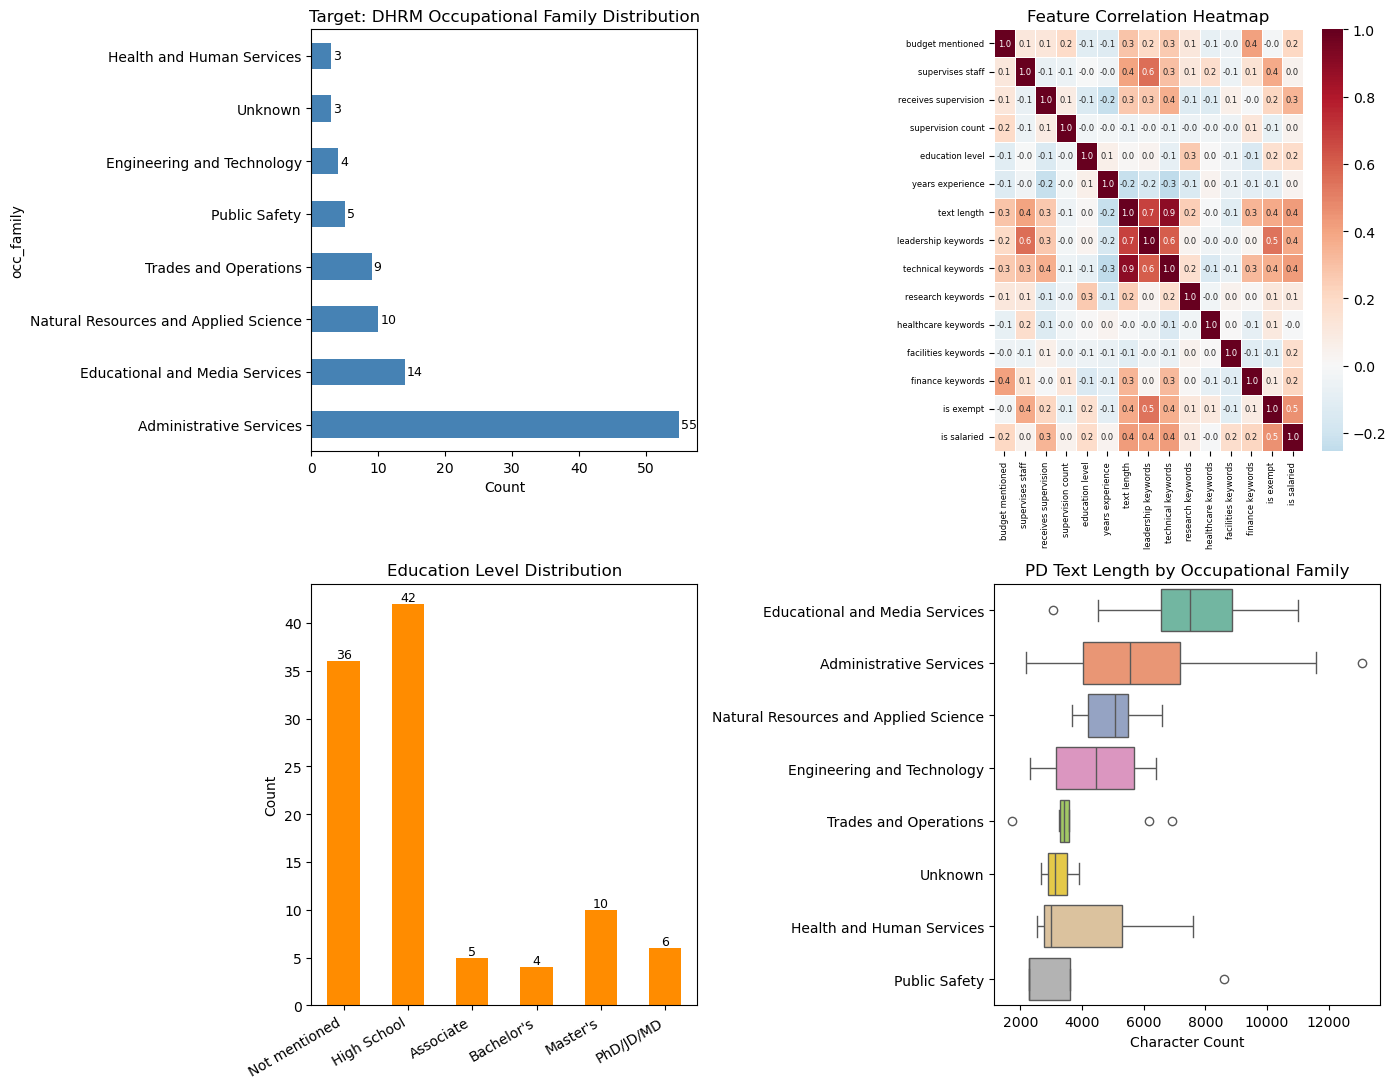

Plots saved to reports/a4_feature_engineering_plots.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Class distribution — prediction target
ax = axes[0, 0]
occ_counts = df["occ_family"].value_counts()
occ_counts.plot.barh(ax=ax, color="steelblue")
ax.set_title("Target: DHRM Occupational Family Distribution")
ax.set_xlabel("Count")
for i, v in enumerate(occ_counts.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)

# 2. Feature correlation heatmap
ax = axes[0, 1]
corr = df[feature_cols].corr()
sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0, fmt=".1f",
            annot=True, annot_kws={"size": 6}, linewidths=0.5,
            xticklabels=[c.replace("_", " ") for c in feature_cols],
            yticklabels=[c.replace("_", " ") for c in feature_cols])
ax.set_title("Feature Correlation Heatmap")
ax.tick_params(axis="both", labelsize=6)

# 3. Education level distribution
ax = axes[1, 0]
edu_labels = {0: "Not mentioned", 1: "High School", 2: "Associate",
              3: "Bachelor's", 4: "Master's", 5: "PhD/JD/MD"}
edu_counts = df["education_level"].value_counts().sort_index()
edu_counts.index = [edu_labels.get(i, str(i)) for i in edu_counts.index]
edu_counts.plot.bar(ax=ax, color="darkorange")
ax.set_title("Education Level Distribution")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
for i, v in enumerate(edu_counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=9)

# 4. Text length by occupational family
ax = axes[1, 1]
order = df.groupby("occ_family")["text_length"].median().sort_values(ascending=False).index
sns.boxplot(data=df, y="occ_family", x="text_length", order=order, ax=ax, palette="Set2")
ax.set_title("PD Text Length by Occupational Family")
ax.set_xlabel("Character Count")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "a4_feature_engineering_plots.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved to reports/a4_feature_engineering_plots.png")

In [12]:
# Export feature matrix + labels to CSV
export_cols = feature_cols + ["compensation_grade", "job_family", "occ_family"]
features_df = df[export_cols].copy()

output_path = os.path.join(PROJECT_ROOT, "data", "training", "workday_features.csv")
features_df.to_csv(output_path, index=False)
print(f"Exported {len(features_df)} rows x {len(features_df.columns)} columns to data/training/workday_features.csv")
print(f"\nColumns: {list(features_df.columns)}")

Exported 103 rows x 18 columns to data/training/workday_features.csv

Columns: ['budget_mentioned', 'supervises_staff', 'receives_supervision', 'supervision_count', 'education_level', 'years_experience', 'text_length', 'leadership_keywords', 'technical_keywords', 'research_keywords', 'healthcare_keywords', 'facilities_keywords', 'finance_keywords', 'is_exempt', 'is_salaried', 'compensation_grade', 'job_family', 'occ_family']


## Summary
- Extracted **15 features** from 103 position descriptions
- Mapped **30 W&M job families** to **7 DHRM occupational families** (+ 3 Unknown from NaN)
- Output: `data/workday_features.csv` -- ready for H2O AutoML (A5)

## Next Steps (A5)
- Install H2O (follow Big Data lab process)
- Train multi-class classifier on 7 occupational families
- Stratified CV (important due to class imbalance)
- Evaluate: macro F1, top-3 accuracy, confusion matrix
- Interpret: SHAP (global + local), PDP, variable importance